In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.metrics import r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools 

from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima_model import ARIMAResults
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('euro_exchange_rate.csv')
df

,Date,USD,JPY,BGN,CYP,CZK,DKK,EEK,GBP,HUF,...,INR,KRW,MXN,MYR,NZD,PHP,SGD,THB,ZAR,Unnamed: 42
0,2023-03-23,1.0879,142.87,1.9558,NaN,23.658,7.4482,NaN,0.88523,384.75,...,89.4810,1396.18,20.1915,4.8063,1.7373,59.125,1.4434,37.119,19.7787,NaN
1,2023-03-22,1.0785,143.13,1.9558,NaN,23.722,7.4472,NaN,0.87925,388.55,...,89.0800,1406.43,20.0036,4.8047,1.7362,58.683,1.4391,37.100,19.8529,NaN
2,2023-03-21,1.0776,142.63,1.9558,NaN,23.846,7.4465,NaN,0.88033,391.58,...,89.0308,1406.34,20.1454,4.8196,1.7412,58.485,1.4392,36.929,19.9659,NaN
3,2023-03-20,1.0717,140.77,1.9558,NaN,23.988,7.4450,NaN,0.87560,399.21,...,88.4900,1401.82,20.3003,4.8076,1.7106,58.281,1.4354,36.513,19.7861,NaN
4,2023-03-17,1.0623,140.57,1.9558,NaN,23.948,7.4450,NaN,0.87488,395.93,...,87.7870,1389.84,19.9829,4.7649,1.7014,58.118,1.4262,36.246,19.4988,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6201,1999-01-08,1.1659,130.09,NaN,0.58187,34.938,7.4433,15.6466,0.70940,250.15,...,NaN,1366.73,NaN,NaN,2.1557,NaN,1.9537,NaN,6.7855,NaN
6202,1999-01-07,1.1632,129.43,NaN,0.58187,34.886,7.4431,15.6466,0.70585,250.09,...,NaN,1337.16,NaN,NaN,2.1531,NaN,1.9436,NaN,6.8283,NaN
6203,1999-01-06,1.1743,131.42,NaN,0.58200,34.850,7.4452,15.6466,0.70760,250.67,...,NaN,1359.54,NaN,NaN,2.1890,NaN,1.9699,NaN,6.7307,NaN
6204,1999-01-05,1.1790,130.96,NaN,0.58230,34.917,7.4495,15.6466,0.71220,250.80,...,NaN,1373.01,NaN,NaN,2.2011,NaN,1.9655,NaN,6.7975,NaN


In [3]:
df.columns

Index(['Date', 'USD', 'JPY', 'BGN', 'CYP', 'CZK', 'DKK', 'EEK', 'GBP', 'HUF',
       'LTL', 'LVL', 'MTL', 'PLN', 'ROL', 'RON', 'SEK', 'SIT', 'SKK', 'CHF',
       'ISK', 'NOK', 'HRK', 'RUB', 'TRL', 'TRY', 'AUD', 'BRL', 'CAD', 'CNY',
       'HKD', 'IDR', 'ILS', 'INR', 'KRW', 'MXN', 'MYR', 'NZD', 'PHP', 'SGD',
       'THB', 'ZAR', 'Unnamed: 42'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6206 entries, 0 to 6205
Data columns (total 43 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         6206 non-null   object 
 1   USD          6206 non-null   float64
 2   JPY          6206 non-null   float64
 3   BGN          5808 non-null   float64
 4   CYP          2304 non-null   float64
 5   CZK          6206 non-null   float64
 6   DKK          6206 non-null   float64
 7   EEK          3074 non-null   float64
 8   GBP          6206 non-null   float64
 9   HUF          6206 non-null   float64
 10  LTL          4097 non-null   float64
 11  LVL          3842 non-null   float64
 12  MTL          2304 non-null   float64
 13  PLN          6206 non-null   float64
 14  ROL          1664 non-null   float64
 15  RON          4542 non-null   float64
 16  SEK          6206 non-null   float64
 17  SIT          2049 non-null   float64
 18  SKK          2560 non-null   float64
 19  CHF   

In [5]:
df=df.drop('Unnamed: 42', axis=1)
df.columns

Index(['Date', 'USD', 'JPY', 'BGN', 'CYP', 'CZK', 'DKK', 'EEK', 'GBP', 'HUF',
       'LTL', 'LVL', 'MTL', 'PLN', 'ROL', 'RON', 'SEK', 'SIT', 'SKK', 'CHF',
       'ISK', 'NOK', 'HRK', 'RUB', 'TRL', 'TRY', 'AUD', 'BRL', 'CAD', 'CNY',
       'HKD', 'IDR', 'ILS', 'INR', 'KRW', 'MXN', 'MYR', 'NZD', 'PHP', 'SGD',
       'THB', 'ZAR'],
      dtype='object')

In [7]:
df.isnull().sum()

Date       0
USD        0
JPY        0
BGN      398
CYP     3902
CZK        0
DKK        0
EEK     3132
GBP        0
HUF        0
LTL     2109
LVL     2364
MTL     3902
PLN        0
ROL     4542
RON     1664
SEK        0
SIT     4157
SKK     3646
CHF        0
ISK     2341
NOK        0
HRK     1658
RUB     1873
TRL     4669
TRY     1537
AUD        0
BRL     2304
CAD        0
CNY     1599
HKD        0
IDR     1599
ILS     3074
INR     2560
KRW        0
MXN     2304
MYR     1599
NZD        0
PHP     1599
SGD        0
THB     1599
ZAR        0
dtype: int64

In [8]:
df=df.fillna(df.mean())

In [9]:
print(df)

            Date     USD     JPY       BGN       CYP     CZK     DKK      EEK  \
0     2023-03-23  1.0879  142.87  1.955800  0.578354  23.658  7.4482  15.6466   
1     2023-03-22  1.0785  143.13  1.955800  0.578354  23.722  7.4472  15.6466   
2     2023-03-21  1.0776  142.63  1.955800  0.578354  23.846  7.4465  15.6466   
3     2023-03-20  1.0717  140.77  1.955800  0.578354  23.988  7.4450  15.6466   
4     2023-03-17  1.0623  140.57  1.955800  0.578354  23.948  7.4450  15.6466   
...          ...     ...     ...       ...       ...     ...     ...      ...   
6201  1999-01-08  1.1659  130.09  1.954605  0.581870  34.938  7.4433  15.6466   
6202  1999-01-07  1.1632  129.43  1.954605  0.581870  34.886  7.4431  15.6466   
6203  1999-01-06  1.1743  131.42  1.954605  0.582000  34.850  7.4452  15.6466   
6204  1999-01-05  1.1790  130.96  1.954605  0.582300  34.917  7.4495  15.6466   
6205  1999-01-04  1.1789  133.73  1.954605  0.582310  35.107  7.4501  15.6466   

          GBP     HUF  ... 

In [10]:
df.isnull().sum()

Date    0
USD     0
JPY     0
BGN     0
CYP     0
CZK     0
DKK     0
EEK     0
GBP     0
HUF     0
LTL     0
LVL     0
MTL     0
PLN     0
ROL     0
RON     0
SEK     0
SIT     0
SKK     0
CHF     0
ISK     0
NOK     0
HRK     0
RUB     0
TRL     0
TRY     0
AUD     0
BRL     0
CAD     0
CNY     0
HKD     0
IDR     0
ILS     0
INR     0
KRW     0
MXN     0
MYR     0
NZD     0
PHP     0
SGD     0
THB     0
ZAR     0
dtype: int64

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6206 entries, 0 to 6205
Data columns (total 42 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   USD     6206 non-null   float64       
 2   JPY     6206 non-null   float64       
 3   BGN     6206 non-null   float64       
 4   CYP     6206 non-null   float64       
 5   CZK     6206 non-null   float64       
 6   DKK     6206 non-null   float64       
 7   EEK     6206 non-null   float64       
 8   GBP     6206 non-null   float64       
 9   HUF     6206 non-null   float64       
 10  LTL     6206 non-null   float64       
 11  LVL     6206 non-null   float64       
 12  MTL     6206 non-null   float64       
 13  PLN     6206 non-null   float64       
 14  ROL     6206 non-null   float64       
 15  RON     6206 non-null   float64       
 16  SEK     6206 non-null   float64       
 17  SIT     6206 non-null   float64       
 18  SKK     

In [12]:
df5=df.loc[:,['Date','USD', 'JPY', 'GBP', 'AUD', 'CAD']]
df5.head()

,Date,USD,JPY,GBP,AUD,CAD
0,2023-03-23,1.0879,142.87,0.88523,1.6242,1.4875
1,2023-03-22,1.0785,143.13,0.87925,1.6132,1.4782
2,2023-03-21,1.0776,142.63,0.88033,1.6136,1.4726
3,2023-03-20,1.0717,140.77,0.87560,1.5978,1.4669
4,2023-03-17,1.0623,140.57,0.87488,1.5874,1.4584


In [13]:
df5.sort_values(by='Date', inplace = True)

In [14]:
df5.head()

,Date,USD,JPY,GBP,AUD,CAD
6205,1999-01-04,1.1789,133.73,0.71110,1.9100,1.8004
6204,1999-01-05,1.1790,130.96,0.71220,1.8944,1.7965
6203,1999-01-06,1.1743,131.42,0.70760,1.8820,1.7711
6202,1999-01-07,1.1632,129.43,0.70585,1.8474,1.7602
6201,1999-01-08,1.1659,130.09,0.70940,1.8406,1.7643


In [15]:
df5_list = ['USD', 'JPY', 'GBP', 'AUD', 'CAD']

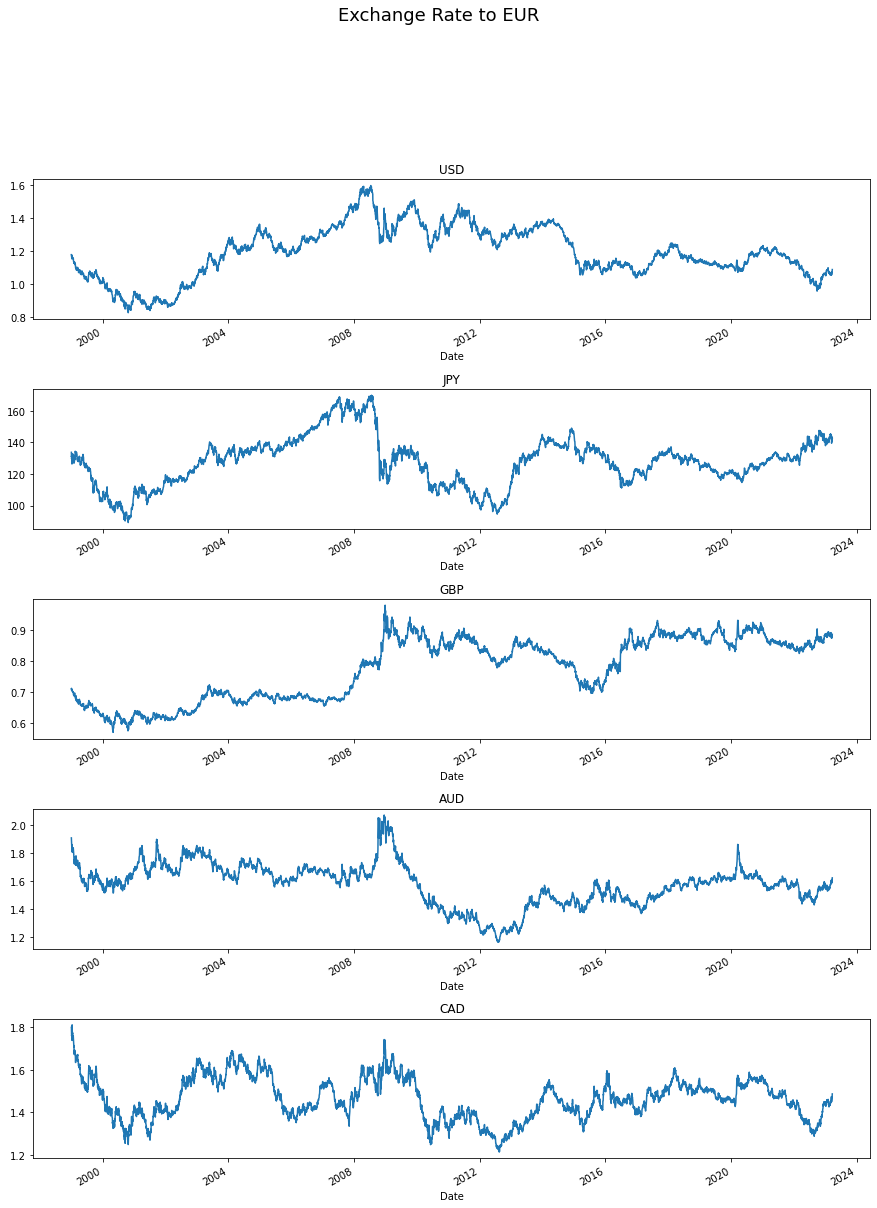

In [16]:
plt.figure(figsize=(15,20))
plt.subplots_adjust(hspace=0.5)
plt.suptitle('Exchange Rate to EUR', fontsize=18,y=1)

# loop through the length of currencies and keep track of index
for n, currency in enumerate(df5_list):
    # add new subplot iteratively
    ax = plt.subplot(5,1,n+1)
    df5.plot(x='Date',y=currency,ax=ax, legend=None)
    # chart formating
    ax.set_title(currency.upper()) 

In [17]:
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.models.annotations import Title
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.palettes import Spectral10

source = ColumnDataSource(df5)

output_notebook()

p = figure(plot_height = 500, \
           plot_width = 900, \
           x_axis_type = 'datetime')

p.line(x='Date', y='USD', legend_label = 'USD', source=source, color=Spectral10[1], line_width=4)
p.line(x='Date', y='JPY', legend_label = 'JPY', source=source, color=Spectral10[2], line_width=4)
p.line(x='Date', y='GBP', legend_label = 'GBP', source=source, color=Spectral10[3], line_width=4)
p.line(x='Date', y='AUD', legend_label = 'AUD', source=source, color=Spectral10[4], line_width=4)
p.line(x='Date', y='CAD', legend_label = 'CAD', source=source, color=Spectral10[5], line_width=4)


p.xaxis[0].ticker.desired_num_ticks = 20

p.xaxis.axis_label = 'Year'
p.yaxis.axis_label = 'Exchange Rate'

t = Title()
t.text = 'Exchange Rate: Top Countries/USD'
p.title = t

hover = HoverTool(tooltips = [
                  ('USD','@USD'),\
                  ('JPY', '@JPY'),\
                  ('GBP', '@GBP'),\
                  ('AUD', '@AUD'),\
                  ('CAD', '@CAD')])
p.add_tools(hover)
show(p)

Loading BokehJS ...

# Stationary check

## Perform the Augmented Dickey-Fuller (ADF)

Method 1: Perform the Augmented Dickey-Fuller (ADF) We can alscheck for staionarity with statistical tests.

A Time Series is said to be stationary if its statistical properties such as mean, variance remain constant over time.

Most of the Time Series models work on the assumption that the TS is stationary. Major reason for this is that there are many ways in which a series can be non-stationary, but only one way for stationarity.

Intuitively, we can say that if a Time Series has a particular behaviour over time, there is a very high probability that it will follow the same in the future.

Also, the theories related to stationary series are more mature and easier to implement as compared to non-stationary series.

The Dickey Fuller test is used to check the stationarity of the series. The test determines how stringly a time series is defined by a trend. The null hypothesis of the test is that time series is not stationary( has some time-dependent structure). The test result is made up of a Test Statistic and some Critical Values for different confidence levels. If P-VALUE is less than the significance level , the null hypothesis is rejected and the series is stationary.

The most commonly used is the ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. The ADF tests give the following results – test statistic, p-value, and critical value at 1%, 5%, and 10% confidence intervals

The test result is made up of a Test Statistic and some Critical Values for different confidence levels. If P-VALUE is less than the significance level , the null hypothesis is rejected and the series is stationary.

if p_value > 0.05 and the stat_value > any of the critical values:

Acceptiong the Null Hypothesis i.e Dataset is Non-Stationary else:

Rejecting the Null Hypothesis i.e Dataset is Stationary

In [18]:
from statsmodels.tsa.stattools import adfuller
from numpy import log

In [19]:
def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)
    for key,val in result[4].items():
        out[f'critical value ({key})']=val
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

In [20]:
adf_test(df5['USD'])

Augmented Dickey-Fuller Test: 
ADF test statistic        -1.739994
p-value                    0.410633
# lags used               12.000000
# observations          6193.000000
critical value (1%)       -3.431406
critical value (5%)       -2.862007
critical value (10%)      -2.567018
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [21]:
adf_test(df5['JPY'])

Augmented Dickey-Fuller Test: 
ADF test statistic        -2.232377
p-value                    0.194705
# lags used                0.000000
# observations          6205.000000
critical value (1%)       -3.431404
critical value (5%)       -2.862006
critical value (10%)      -2.567018
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [22]:
adf_test(df5['GBP'])

Augmented Dickey-Fuller Test: 
ADF test statistic        -1.364219
p-value                    0.599305
# lags used               22.000000
# observations          6183.000000
critical value (1%)       -3.431408
critical value (5%)       -2.862008
critical value (10%)      -2.567019
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [23]:
adf_test(df5['AUD'])

Augmented Dickey-Fuller Test: 
ADF test statistic        -2.865877
p-value                    0.049462
# lags used                5.000000
# observations          6200.000000
critical value (1%)       -3.431405
critical value (5%)       -2.862006
critical value (10%)      -2.567018
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [24]:
adf_test(df5['CAD'])

Augmented Dickey-Fuller Test: 
ADF test statistic        -3.962444
p-value                    0.001620
# lags used               16.000000
# observations          6189.000000
critical value (1%)       -3.431407
critical value (5%)       -2.862007
critical value (10%)      -2.567019
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [25]:
#Transform non-stationary to stationary
df5_difference = df5.diff()

In [26]:
#Stationary
adf_test(df5_difference['USD'])

Augmented Dickey-Fuller Test: 
ADF test statistic       -22.494993
p-value                    0.000000
# lags used               11.000000
# observations          6193.000000
critical value (1%)       -3.431406
critical value (5%)       -2.862007
critical value (10%)      -2.567018
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [27]:
#Stationary
adf_test(df5_difference['JPY'])

Augmented Dickey-Fuller Test: 
ADF test statistic       -79.447008
p-value                    0.000000
# lags used                0.000000
# observations          6204.000000
critical value (1%)       -3.431404
critical value (5%)       -2.862006
critical value (10%)      -2.567018
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [28]:
#Stationary
adf_test(df5_difference['GBP'])

Augmented Dickey-Fuller Test: 
ADF test statistic     -1.711481e+01
p-value                 7.323911e-30
# lags used             2.100000e+01
# observations          6.183000e+03
critical value (1%)    -3.431408e+00
critical value (5%)    -2.862008e+00
critical value (10%)   -2.567019e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [29]:
#Stationary
adf_test(df5_difference['AUD'])

Augmented Dickey-Fuller Test: 
ADF test statistic       -37.588584
p-value                    0.000000
# lags used                4.000000
# observations          6200.000000
critical value (1%)       -3.431405
critical value (5%)       -2.862006
critical value (10%)      -2.567018
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [30]:
#Stationary
adf_test(df5_difference['CAD'])

Augmented Dickey-Fuller Test: 
ADF test statistic       -21.391541
p-value                    0.000000
# lags used               15.000000
# observations          6189.000000
critical value (1%)       -3.431407
critical value (5%)       -2.862007
critical value (10%)      -2.567019
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


## Time-step feature application

As linear regression data type needs to be numeric. However, our dataset 'Date' type is datetime. Our time series doesn't have any missing dates as well, created a time dummy by counting out the length of the time series.

In [31]:
df5['Time'] = np.arange(start=1, stop=(len(df5.index)+1), step=1 )

In [32]:
df5

,Date,USD,JPY,GBP,AUD,CAD,Time
6205,1999-01-04,1.1789,133.73,0.71110,1.9100,1.8004,1
6204,1999-01-05,1.1790,130.96,0.71220,1.8944,1.7965,2
6203,1999-01-06,1.1743,131.42,0.70760,1.8820,1.7711,3
6202,1999-01-07,1.1632,129.43,0.70585,1.8474,1.7602,4
6201,1999-01-08,1.1659,130.09,0.70940,1.8406,1.7643,5
...,...,...,...,...,...,...,...
4,2023-03-17,1.0623,140.57,0.87488,1.5874,1.4584,6202
3,2023-03-20,1.0717,140.77,0.87560,1.5978,1.4669,6203
2,2023-03-21,1.0776,142.63,0.88033,1.6136,1.4726,6204
1,2023-03-22,1.0785,143.13,0.87925,1.6132,1.4782,6205


In [33]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   USD     6206 non-null   float64       
 2   JPY     6206 non-null   float64       
 3   GBP     6206 non-null   float64       
 4   AUD     6206 non-null   float64       
 5   CAD     6206 non-null   float64       
 6   Time    6206 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(1)
memory usage: 363.6 KB


We select five currencies 'USD', 'JPY', 'GBP', 'AUD' and 'CAD' for our prediction.

## USD/EUR

In [339]:
df5_usd = df5[['Date', 'USD','Time']]
df5_usd.columns = ['Date', 'USD','Time']
df5_usd.sort_values(by='Date', inplace = True)

In [340]:
df5_usd

,Date,USD,Time
6205,1999-01-04,1.1789,1
6204,1999-01-05,1.1790,2
6203,1999-01-06,1.1743,3
6202,1999-01-07,1.1632,4
6201,1999-01-08,1.1659,5
...,...,...,...
4,2023-03-17,1.0623,6202
3,2023-03-20,1.0717,6203
2,2023-03-21,1.0776,6204
1,2023-03-22,1.0785,6205


First prediction is on USD/EUR. Therefore, created a new dataframe called df5_usd specifically for the model.

In [341]:
df5_usd['Date'] = pd.to_datetime(df5_usd['Date'])
df5_usd['Date']

6205   1999-01-04
6204   1999-01-05
6203   1999-01-06
6202   1999-01-07
6201   1999-01-08
          ...    
4      2023-03-17
3      2023-03-20
2      2023-03-21
1      2023-03-22
0      2023-03-23
Name: Date, Length: 6206, dtype: datetime64[ns]

In [342]:
#Year
df5_usd['Date'].dt.year

6205    1999
6204    1999
6203    1999
6202    1999
6201    1999
        ... 
4       2023
3       2023
2       2023
1       2023
0       2023
Name: Date, Length: 6206, dtype: int64

In [343]:
#Month
df5_usd['Date'].dt.month

6205    1
6204    1
6203    1
6202    1
6201    1
       ..
4       3
3       3
2       3
1       3
0       3
Name: Date, Length: 6206, dtype: int64

In [344]:
#Day
df5_usd['Date'].dt.day

6205     4
6204     5
6203     6
6202     7
6201     8
        ..
4       17
3       20
2       21
1       22
0       23
Name: Date, Length: 6206, dtype: int64

In [345]:
df5_usd['year']=df5_usd['Date'].dt.year
df5_usd['month']=df5_usd['Date'].dt.month
df5_usd['day']=df5_usd['Date'].dt.day
df5_usd.head()

,Date,USD,Time,year,month,day
6205,1999-01-04,1.1789,1,1999,1,4
6204,1999-01-05,1.1790,2,1999,1,5
6203,1999-01-06,1.1743,3,1999,1,6
6202,1999-01-07,1.1632,4,1999,1,7
6201,1999-01-08,1.1659,5,1999,1,8


Extracted year, month and day data from 'Date' variable to prepare for Linear regression model as when the date data is extracted it's data type is integer by default.

In [346]:
df5_usd.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   USD     6206 non-null   float64       
 2   Time    6206 non-null   int32         
 3   year    6206 non-null   int64         
 4   month   6206 non-null   int64         
 5   day     6206 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 315.1 KB


In [347]:
#Lineplot- groupby by year and it's mean.
data_year = df5_usd.groupby('year')['USD'].mean().reset_index(name='USD')

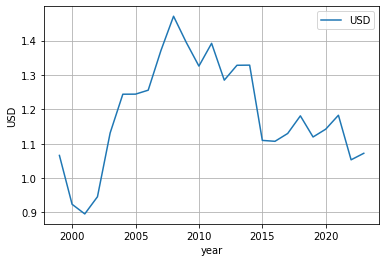

In [348]:
# Using lineplot to visualize the Time plot
sns.lineplot(data=data_year, x="year", y="USD", label='USD')
plt.figsize=(5,3)
plt.grid()
plt.show()

Figure: USD and Time lineplot

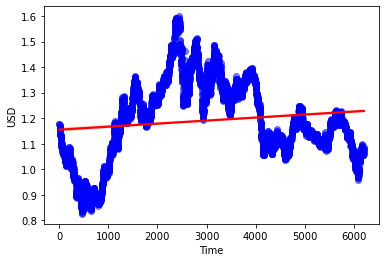

In [349]:
sns.regplot(x="Time", y="USD", data=df5_usd, 
            scatter_kws = {"color": "blue", "alpha": 0.5},
            line_kws = {"color": "red"});
plt.show()

Figure. USD - Scatter plot and linear regression line 

## Linear regression model 

### Split data

The dataset will be split into train set and test set. The test will consist of data from 2019 to 2023, while the rest of the data will be included in the training set.

In [350]:
#Import sklearn Linear regression library
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [351]:
X = df5_usd.loc[:, ['Time']]  # features
y = df5_usd.loc[:, 'USD']  # target

#X_day = df5_usd[:, ['Time']] 
#y_day = df5_usd[:, 'USD']

In [352]:
X = np.log(X)

In [353]:
#Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
#X_train,     X_test,     Y_train,     Y_test     = train_test_split(X,     Y,     test_size=.20, random_state=0)

In [354]:
X_train.shape, X_test.shape

((4964, 1), (1242, 1))

In [355]:
y_train.shape, y_test.shape

((4964,), (1242,))

### Build the model

In [356]:
# Define model
model = LinearRegression()

#Fit model
model.fit(X_train, y_train)

LinearRegression()

### Prediction

Predict USD rate by parsing a Time variable that corresponds to Date. 

In [357]:
#Predict model
y_pred = model.predict(X_test)

In [358]:
y_pred

array([1.29603406, 1.29605177, 1.29606947, ..., 1.31562213, 1.3156363 ,
       1.31565047])

In [359]:
len(y_pred)

1242

In [565]:
#Prediction plot but not working
plt.figure(figsize=(14,5))
plt.plot(y_train['USD'].values, label = 'Train')   
plt.plot([None for i in y_train.values] + [x for x in y_test['rate'].values], label = 'Test')
plt.plot([None for i in y_train.values] + [x for x in y_test['RegOnTime'].values], label = 'Regression On Time')
plt.title('Exchange rate of USD Linear Regression Plot', family='Arial', fontsize=20)
plt.xlabel('Time', fontsize=18)
plt.ylabel('USD', fontsize=18)
plt.legend(loc = 'best')

KeyError: 'USD'

<Figure size 1008x360 with 0 Axes>

### Model evaluation

In [361]:
#Import Sklearn library
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
import math

In [362]:
#Ordinary least square
def sum_square_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred) #transform variables to numpy
    error =np.subtract(y_true, y_pred) #Find error by subtracting  
    errorSquare = np.power(error, 2) #After error is found find square power of two of the error
    errorSquareSum = np.sum(errorSquare) #After error square power, find total sum of error 
    meanErrorSquareSum = errorSquareSum /(len(y_pred)) #To find mean Error square sum, divide sum of error square power by the length of prediction
    return meanErrorSquareSum*100 #multiply mean error square by 100 to find percentage

In [363]:
accurracy_sum = 100 - sum_square_percentage_error(y_test,y_pred)
accurracy_sum

96.39083866440147

In [364]:
#Mean absolute to check how much is is there mistake in our Linear regression model
def mean_absolute_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

In [365]:
#Checking accuracy
result_mae = 100 - mean_absolute_error(y_test,y_pred)
result_mae

99.83652307597731

In [366]:
def root_mean_square_error(y_true, y_pred): 
    np.sqrt(mean_squared_error(y_test, y_pred))
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [367]:
result_rmse = root_mean_square_error(y_test,y_pred)
result_rmse

0.18997792860220722

In [368]:
#def mean_absolute_percentage_error(y_t_day, y_pred_day):
 #   mape = np.mean(np.abs((y_true_day - y_pred_day)/y_true_day))*100
  #  return mape

In [369]:
#result_mape = mean_absolute_percentage_error(y_true_day, y_pred_day)
#result_mape

In [375]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = (1-mse)*100

print(f'mse: {mse}')           
print(f'mae: {mae}')
print(f'mape: {mape}')
print(f'rmse: {rmse}')      
print(f'accuracy: {accuracy}')  

mse: 0.03609161335598534
mae: 0.16347692402268194
mape: 0.16347692402268194
rmse: 0.18997792860220722
accuracy: 96.39083866440147


## JPY/EUR

Time-step feature
As linear regression data type needs to be numeric. However, our dataset 'Date' type is datetime. Our time series doesn't have any missing dates as well, created a time dummy by counting out the length of the time series.

In [538]:
df5_jpy = df5[['Date', 'JPY','Time']]
df5_jpy.columns = ['Date', 'JPY','Time']
df5_jpy.sort_values(by='Date', inplace = True)

In [539]:
df5_jpy

,Date,JPY,Time
6205,1999-01-04,133.73,1
6204,1999-01-05,130.96,2
6203,1999-01-06,131.42,3
6202,1999-01-07,129.43,4
6201,1999-01-08,130.09,5
...,...,...,...
4,2023-03-17,140.57,6202
3,2023-03-20,140.77,6203
2,2023-03-21,142.63,6204
1,2023-03-22,143.13,6205


First prediction is on USD/EUR. Therefore, created a new dataframe called df5_jpy specifically for the model.

In [540]:
df5_jpy['Date'] = pd.to_datetime(df5_jpy['Date'])
df5_jpy['Date']

6205   1999-01-04
6204   1999-01-05
6203   1999-01-06
6202   1999-01-07
6201   1999-01-08
          ...    
4      2023-03-17
3      2023-03-20
2      2023-03-21
1      2023-03-22
0      2023-03-23
Name: Date, Length: 6206, dtype: datetime64[ns]

In [541]:
#Year
df5_jpy['Date'].dt.year

6205    1999
6204    1999
6203    1999
6202    1999
6201    1999
        ... 
4       2023
3       2023
2       2023
1       2023
0       2023
Name: Date, Length: 6206, dtype: int64

In [542]:
#Month
df5_jpy['Date'].dt.month

6205    1
6204    1
6203    1
6202    1
6201    1
       ..
4       3
3       3
2       3
1       3
0       3
Name: Date, Length: 6206, dtype: int64

In [543]:
#Day
df5_jpy['Date'].dt.day

6205     4
6204     5
6203     6
6202     7
6201     8
        ..
4       17
3       20
2       21
1       22
0       23
Name: Date, Length: 6206, dtype: int64

In [544]:
df5_jpy['year']=df5_jpy['Date'].dt.year
df5_jpy['month']=df5_jpy['Date'].dt.month
df5_jpy['day']=df5_jpy['Date'].dt.day
df5_jpy.head()

,Date,JPY,Time,year,month,day
6205,1999-01-04,133.73,1,1999,1,4
6204,1999-01-05,130.96,2,1999,1,5
6203,1999-01-06,131.42,3,1999,1,6
6202,1999-01-07,129.43,4,1999,1,7
6201,1999-01-08,130.09,5,1999,1,8


Extracted year, month and day data from 'Date' variable to prepare for Linear regression model as when the date data is extracted it's data type is integer by default.



In [545]:
df5_jpy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   JPY     6206 non-null   float64       
 2   Time    6206 non-null   int32         
 3   year    6206 non-null   int64         
 4   month   6206 non-null   int64         
 5   day     6206 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 315.1 KB


In [546]:
#Lineplot- groupby by year and it's mean.
data_year = df5_jpy.groupby('year')['JPY'].mean().reset_index(name='JPY')

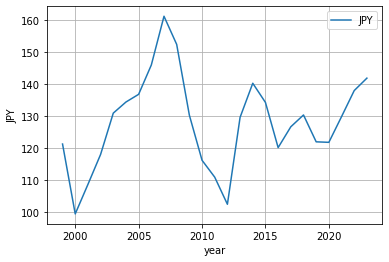

In [547]:
# Using lineplot to visualize the Time plot
sns.lineplot(data=data_year, x="year", y="JPY", label='JPY')
plt.figsize=(5,3)
plt.grid()
plt.show()

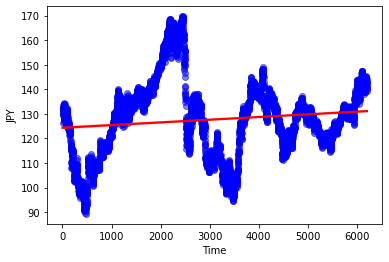

In [548]:
sns.regplot(x="Time", y="JPY", data=df5_jpy, 
            scatter_kws = {"color": "blue", "alpha": 0.5},
            line_kws = {"color": "red"});
plt.show()

Figure. JPY - Scatter plot and linear regression line

## Linear regression model 

### Split data

The dataset will be split into train set and test set. The test will consist of data from 2019 to 2023, while the rest of the data will be included in the training set.

In [549]:
X = df5_jpy.loc[:, ['Time']]  # features
y = df5_jpy.loc[:, 'JPY']  # target

In [550]:
#X = np.log(X)

In [551]:
#Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [552]:
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(4964, 1) (4964,)
(1242, 1) (1242,)


### Build the model

In [553]:
# Define model
model = LinearRegression()

#Fit model
model.fit(X_train, y_train)

LinearRegression()

### Prediction

In [554]:
#Predict model
y_pred = model.predict(X_test)

In [555]:
y_pred

array([131.29160966, 131.29313561, 131.29466155, ..., 133.18225469,
       133.18378064, 133.18530658])


### Model evaluation

In [556]:
#Ordinary least square
def sum_square_percentage_error(y_true_day, y_pred_day): 
    y_true, y_pred = np.array(y_true_day), np.array(y_pred_day) #transform variables to numpy
    error =np.subtract(y_true_day, y_pred_day) #Find error by subtracting  
    errorSquare = np.power(error, 2) #After error is found find square power of two of the error
    errorSquareSum = np.sum(errorSquare) #After error square power, find total sum of error 
    meanErrorSquareSum = errorSquareSum /(len(y_pred_day)) #To find mean Error square sum, divide sum of error square power by the length of prediction
    return meanErrorSquareSum*100 #multiply mean error square by 100 to find percentage

In [557]:
accurracy_sum = 100 - sum_square_percentage_error(y_test,y_pred)
accurracy_sum

-6214.6988980651695

In [558]:
#Mean absolute to check how much is is there mistake in our Linear regression model
def mean_absolute_error(y_true_day, y_pred_day): 
    y_true, y_pred = np.array(y_true_day), np.array(y_pred_day)
    return np.mean(np.abs((y_true_day - y_pred) / y_true_day))

In [559]:
#Checking accuracy
result_mae = 100 - mean_absolute_error(y_test,y_pred)
result_mae

99.94674065707738

In [560]:
def root_mean_square_error(y_true, y_pred): 
    np.sqrt(mean_squared_error(y_test, y_pred))
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [561]:
result_rmse = root_mean_square_error(y_test,y_pred)
result_rmse

7.9465079739878

In [562]:
from sklearn.metrics import r2_score
#score = r2_score(df5_jpy[])

#calculate R-squared of regression model
r_squared = model.score(X, y)

#view R-squared value
print(r_squared)

accuracy = (1-r_squared)*100
print(f'accuracy: {accuracy}')

0.011430921107690506
accuracy: 98.85690788923095


In [564]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = (1-mape)*100


print(f'mse: {mse}')           
print(f'mae: {mae}')
print(f'mape: {mape}')
print(f'rmse: {rmse}')      
print(f'accuracy: {accuracy}')  

mse: 63.1469889806517
mae: 0.05325934292261942
mape: 0.05325934292261932
rmse: 7.9465079739878
accuracy: 94.67406570773807


## GBP/EUR

In [457]:
df5_gbp = df5[['Date', 'GBP','Time']]
df5_gbp.columns = ['Date', 'GBP','Time']
df5_gbp.sort_values(by='Date', inplace = True)

In [458]:
df5_gbp

,Date,GBP,Time
6205,1999-01-04,0.71110,1
6204,1999-01-05,0.71220,2
6203,1999-01-06,0.70760,3
6202,1999-01-07,0.70585,4
6201,1999-01-08,0.70940,5
...,...,...,...
4,2023-03-17,0.87488,6202
3,2023-03-20,0.87560,6203
2,2023-03-21,0.88033,6204
1,2023-03-22,0.87925,6205


In [459]:
df5_gbp['Date'] = pd.to_datetime(df5_gbp['Date'])
df5_gbp['Date']

6205   1999-01-04
6204   1999-01-05
6203   1999-01-06
6202   1999-01-07
6201   1999-01-08
          ...    
4      2023-03-17
3      2023-03-20
2      2023-03-21
1      2023-03-22
0      2023-03-23
Name: Date, Length: 6206, dtype: datetime64[ns]

In [460]:
#Year
df5_gbp['Date'].dt.year

6205    1999
6204    1999
6203    1999
6202    1999
6201    1999
        ... 
4       2023
3       2023
2       2023
1       2023
0       2023
Name: Date, Length: 6206, dtype: int64

In [461]:
#Month
df5_gbp['Date'].dt.month

6205    1
6204    1
6203    1
6202    1
6201    1
       ..
4       3
3       3
2       3
1       3
0       3
Name: Date, Length: 6206, dtype: int64

In [462]:
#Day
df5_gbp['Date'].dt.day

6205     4
6204     5
6203     6
6202     7
6201     8
        ..
4       17
3       20
2       21
1       22
0       23
Name: Date, Length: 6206, dtype: int64

In [463]:
df5_gbp['year']=df5_gbp['Date'].dt.year
df5_gbp['month']=df5_gbp['Date'].dt.month
df5_gbp['day']=df5_gbp['Date'].dt.day
df5_gbp

,Date,GBP,Time,year,month,day
6205,1999-01-04,0.71110,1,1999,1,4
6204,1999-01-05,0.71220,2,1999,1,5
6203,1999-01-06,0.70760,3,1999,1,6
6202,1999-01-07,0.70585,4,1999,1,7
6201,1999-01-08,0.70940,5,1999,1,8
...,...,...,...,...,...,...
4,2023-03-17,0.87488,6202,2023,3,17
3,2023-03-20,0.87560,6203,2023,3,20
2,2023-03-21,0.88033,6204,2023,3,21
1,2023-03-22,0.87925,6205,2023,3,22


In [464]:
df5_gbp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   GBP     6206 non-null   float64       
 2   Time    6206 non-null   int32         
 3   year    6206 non-null   int64         
 4   month   6206 non-null   int64         
 5   day     6206 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 315.1 KB


In [465]:
#Lineplot- groupby by year and it's mean.
data_year = df5_gbp.groupby('year')['GBP'].mean().reset_index(name='GBP')

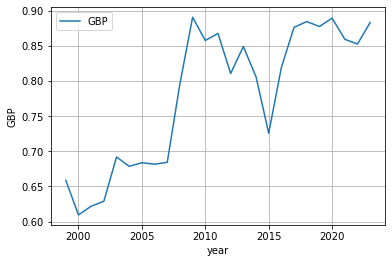

In [466]:
# Using lineplot to visualize the Time plot
sns.lineplot(data=data_year, x="year", y="GBP", label='GBP')
plt.figsize=(5,3)
plt.grid()
plt.show()

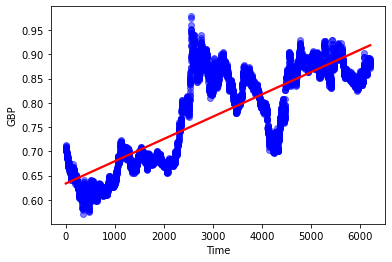

In [467]:
sns.regplot(x="Time", y="GBP", data=df5_gbp, 
            scatter_kws = {"color": "blue", "alpha": 0.5},
            line_kws = {"color": "red"});
plt.show()

## Linear regression model

### Split data

The dataset will be split into train set and test set. The test will consist of data from 2019 to 2023, while the rest of the data will be included in the training set.

In [468]:
X = df5_gbp.loc[:, ['Time']]  # features
y = df5_gbp.loc[:, 'GBP']  # target

In [469]:
#Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [470]:
X_train.shape, X_test.shape

((4964, 1), (1242, 1))

In [471]:
y_train.shape, y_test.shape

((4964,), (1242,))

### Build the model

In [472]:
# Define model
model = LinearRegression()

#Fit model
model.fit(X_train, y_train)

LinearRegression()

### Prediction

In [473]:
#Predict model
y_pred = model.predict(X_test)

In [474]:
y_pred

array([0.8853782 , 0.88543186, 0.88548552, ..., 0.95186142, 0.95191508,
       0.95196873])

In [475]:
y_train.shape, y_test.shape

((4964,), (1242,))

### Model evaluation

In [478]:
#Mean absolute to check how much is is there mistake in our Linear regression model
def mean_absolute_error(y_true_day, y_pred_day): 
    y_true, y_pred = np.array(y_true_day), np.array(y_pred_day)
    return np.mean(np.abs((y_true_day - y_pred) / y_true_day))

In [536]:
#Checking accuracy
result_mse = 100 - mean_absolute_error(y_test,y_pred)
result_mse

99.94658608186666

In [480]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = (1-mape)*100

print(f'mse: {mse}')           
print(f'mae: {mae}')
print(f'mape: {mape}')
print(f'rmse: {rmse}') 
print(f'accuracy: {accuracy}')  

mse: 0.003345983823111473
mae: 0.05506911018190371
mape: 0.05506911018190377
rmse: 0.05784447962521119
accuracy: 94.49308898180962


## AUD/EUR

In [481]:
df5_aud = df5[['Date', 'AUD','Time']]
df5_aud.columns = ['Date', 'AUD','Time']
df5_aud.sort_values(by='Date', inplace = True)

In [482]:
df5_aud

,Date,AUD,Time
6205,1999-01-04,1.9100,1
6204,1999-01-05,1.8944,2
6203,1999-01-06,1.8820,3
6202,1999-01-07,1.8474,4
6201,1999-01-08,1.8406,5
...,...,...,...
4,2023-03-17,1.5874,6202
3,2023-03-20,1.5978,6203
2,2023-03-21,1.6136,6204
1,2023-03-22,1.6132,6205


In [483]:
df5_aud['Date'] = pd.to_datetime(df5_aud['Date'])
df5_aud['Date']

6205   1999-01-04
6204   1999-01-05
6203   1999-01-06
6202   1999-01-07
6201   1999-01-08
          ...    
4      2023-03-17
3      2023-03-20
2      2023-03-21
1      2023-03-22
0      2023-03-23
Name: Date, Length: 6206, dtype: datetime64[ns]

In [484]:
#Year
df5_aud['Date'].dt.year

6205    1999
6204    1999
6203    1999
6202    1999
6201    1999
        ... 
4       2023
3       2023
2       2023
1       2023
0       2023
Name: Date, Length: 6206, dtype: int64

In [485]:
#Month
df5_aud['Date'].dt.month

6205    1
6204    1
6203    1
6202    1
6201    1
       ..
4       3
3       3
2       3
1       3
0       3
Name: Date, Length: 6206, dtype: int64

In [486]:
#Day
df5_aud['Date'].dt.day

6205     4
6204     5
6203     6
6202     7
6201     8
        ..
4       17
3       20
2       21
1       22
0       23
Name: Date, Length: 6206, dtype: int64

In [487]:
df5_aud['year']=df5_aud['Date'].dt.year
df5_aud['month']=df5_aud['Date'].dt.month
df5_aud['day']=df5_aud['Date'].dt.day
df5_aud

,Date,AUD,Time,year,month,day
6205,1999-01-04,1.9100,1,1999,1,4
6204,1999-01-05,1.8944,2,1999,1,5
6203,1999-01-06,1.8820,3,1999,1,6
6202,1999-01-07,1.8474,4,1999,1,7
6201,1999-01-08,1.8406,5,1999,1,8
...,...,...,...,...,...,...
4,2023-03-17,1.5874,6202,2023,3,17
3,2023-03-20,1.5978,6203,2023,3,20
2,2023-03-21,1.6136,6204,2023,3,21
1,2023-03-22,1.6132,6205,2023,3,22


In [488]:
df5_aud.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   AUD     6206 non-null   float64       
 2   Time    6206 non-null   int32         
 3   year    6206 non-null   int64         
 4   month   6206 non-null   int64         
 5   day     6206 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 315.1 KB


In [489]:
#Lineplot- groupby by year and it's mean.
data_year = df5_aud.groupby('year')['AUD'].mean().reset_index(name='AUD')

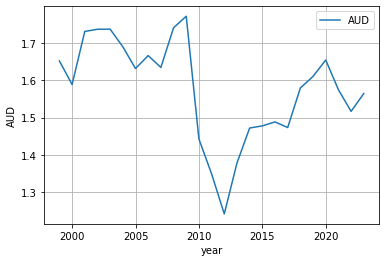

In [490]:
# Using lineplot to visualize the Time plot
sns.lineplot(data=data_year, x="year", y="AUD", label='AUD')
plt.figsize=(5,3)
plt.grid()
plt.show()

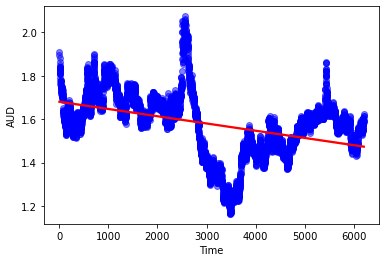

In [491]:
sns.regplot(x="Time", y="AUD", data=df5_aud, 
            scatter_kws = {"color": "blue", "alpha": 0.5},
            line_kws = {"color": "red"});
plt.show()

## Linear regression model

### Split data

In [492]:
X = df5_aud.loc[:, ['Time']]  # features
y = df5_aud.loc[:, 'AUD']  # target

In [493]:
#Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [494]:
X_train.shape, X_test.shape

((4964, 1), (1242, 1))

### Build model

In [495]:
# Define model
model = LinearRegression()

#Fit model
model.fit(X_train, y_train)

LinearRegression()

### Prediction

In [496]:
y_pred = model.predict(X_test)

In [524]:
y_pred

array([1.42020804, 1.42019045, 1.42017286, ..., 1.39841124, 1.39839365,
       1.39837606])

### Model evaluation

In [527]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = (1-rmse)*100

print(f'mse: {mse}')           
print(f'mae: {mae}')
print(f'mape: {mape}')
print(f'rmse: {rmse}')
print(f'accuracy: {accuracy}')  

mse: 0.00781790233374274
mae: 0.05341391813335125
mape: 0.05341391813335122
rmse: 0.08841890258164675
accuracy: 91.15810974183532


## CAD/EUR

In [501]:
df5_cad = df5[['Date', 'CAD','Time']]
df5_cad.columns = ['Date', 'CAD','Time']
df5_cad.sort_values(by='Date', inplace = True)

In [502]:
df5_aud

,Date,AUD,Time,year,month,day
6205,1999-01-04,1.9100,1,1999,1,4
6204,1999-01-05,1.8944,2,1999,1,5
6203,1999-01-06,1.8820,3,1999,1,6
6202,1999-01-07,1.8474,4,1999,1,7
6201,1999-01-08,1.8406,5,1999,1,8
...,...,...,...,...,...,...
4,2023-03-17,1.5874,6202,2023,3,17
3,2023-03-20,1.5978,6203,2023,3,20
2,2023-03-21,1.6136,6204,2023,3,21
1,2023-03-22,1.6132,6205,2023,3,22


In [503]:
df5_cad['Date'] = pd.to_datetime(df5_cad['Date'])
df5_cad['Date']

6205   1999-01-04
6204   1999-01-05
6203   1999-01-06
6202   1999-01-07
6201   1999-01-08
          ...    
4      2023-03-17
3      2023-03-20
2      2023-03-21
1      2023-03-22
0      2023-03-23
Name: Date, Length: 6206, dtype: datetime64[ns]

In [504]:
#Year
df5_aud['Date'].dt.year

6205    1999
6204    1999
6203    1999
6202    1999
6201    1999
        ... 
4       2023
3       2023
2       2023
1       2023
0       2023
Name: Date, Length: 6206, dtype: int64

In [505]:
#Month
df5_aud['Date'].dt.month

6205    1
6204    1
6203    1
6202    1
6201    1
       ..
4       3
3       3
2       3
1       3
0       3
Name: Date, Length: 6206, dtype: int64

In [506]:
#Day
df5_aud['Date'].dt.day

6205     4
6204     5
6203     6
6202     7
6201     8
        ..
4       17
3       20
2       21
1       22
0       23
Name: Date, Length: 6206, dtype: int64

In [507]:
df5_cad['year']=df5_cad['Date'].dt.year
df5_cad['month']=df5_cad['Date'].dt.month
df5_cad['day']=df5_cad['Date'].dt.day
df5_cad

,Date,CAD,Time,year,month,day
6205,1999-01-04,1.8004,1,1999,1,4
6204,1999-01-05,1.7965,2,1999,1,5
6203,1999-01-06,1.7711,3,1999,1,6
6202,1999-01-07,1.7602,4,1999,1,7
6201,1999-01-08,1.7643,5,1999,1,8
...,...,...,...,...,...,...
4,2023-03-17,1.4584,6202,2023,3,17
3,2023-03-20,1.4669,6203,2023,3,20
2,2023-03-21,1.4726,6204,2023,3,21
1,2023-03-22,1.4782,6205,2023,3,22


In [508]:
df5_cad.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6206 entries, 6205 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6206 non-null   datetime64[ns]
 1   CAD     6206 non-null   float64       
 2   Time    6206 non-null   int32         
 3   year    6206 non-null   int64         
 4   month   6206 non-null   int64         
 5   day     6206 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 315.1 KB


In [509]:
#Lineplot- groupby by year and it's mean.
data_year = df5_cad.groupby('year')['CAD'].mean().reset_index(name='CAD')

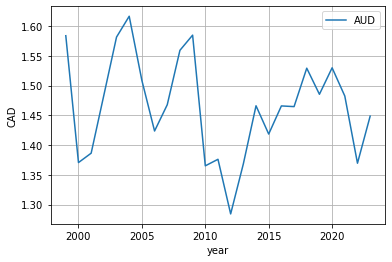

In [510]:
# Using lineplot to visualize the Time plot
sns.lineplot(data=data_year, x="year", y="CAD", label='AUD')
plt.figsize=(5,3)
plt.grid()
plt.show()

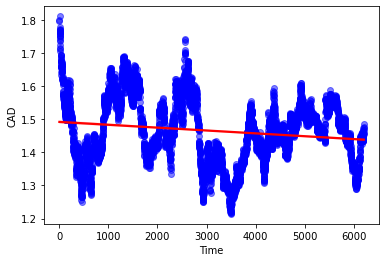

In [511]:
sns.regplot(x="Time", y="CAD", data=df5_cad, 
            scatter_kws = {"color": "blue", "alpha": 0.5},
            line_kws = {"color": "red"});
plt.show()

## Linear regression model

### Split data

In [512]:
X = df5_cad.loc[:, ['Time']]  # features
y = df5_cad.loc[:, 'CAD']  # target

In [513]:
#Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [514]:
X_train.shape, X_test.shape

((4964, 1), (1242, 1))

### Build model

In [515]:
# Define model
model = LinearRegression()

#Fit model
model.fit(X_train, y_train)

LinearRegression()

### Prediction

In [529]:
y_pred = model.predict(X_test)

In [530]:
y_pred

array([1.42020804, 1.42019045, 1.42017286, ..., 1.39841124, 1.39839365,
       1.39837606])

### Model evaluation

In [531]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = (1-mse)*100

print(f'mse: {mse}')           
print(f'mae: {mae}')
print(f'mape: {mape}')
print(f'rmse: {rmse}') 
print(f'accuracy: {accuracy}')  

mse: 0.00781790233374274
mae: 0.05341391813335125
mape: 0.05341391813335122
rmse: 0.08841890258164675
accuracy: 99.21820976662573
